# Upoznavanje sa kreiranim skupom podataka

In [136]:
import argparse
import re
import statistics
from dataclasses import dataclass, field, asdict
from pathlib import Path
import pandas as pd
from collections import Counter
import langdetect
import matplotlib.pyplot as plt
import tqdm

## Analiza tekstualnih dokumenata iz Project Gutenberg skupa podataka

Skripta koja se koristi za analizu tekstualnih dokumenata iz Project Gutenberg skupa podataka.

**Cilj**: Eksplorativna analiza podataka i upoznavanje sa knjiga kroz ceo skup.

**Pitanja na koje analiza odgovara**:

1. START/END marker provera - Koliko knjiga sadrži nekakvu vrstu markera koji označavaju početak/kraj knjige? Radiće se upotrebom regularnih izraza. Korisno kako bi se filtriranje uradilo uz izbegavanje metapodataka knjiga.

1. Proveriti koliko ukupno i koliko često knjige imaju [] i provera da li je taj tekst koristan ili ga je moguće odbaciti - zapisati kao multiset (tekst: broj pojavljivanja).

1. Pogledati koliki broj knjiga nema korisnu sadržinu nakon izdvajanja markera i odbacivanja teksta u [], što se procenjuje na 2 načina (dovoljno je 1 da važi): tekst je manji od 100 reči ili odbačeno je 50% teksta tokom ranijeg procesa. Za same knjige će biti navedeno koliko je reči bilo pre, a koliko posle svega. Takođe će postojati i jedno bool polje for_deleting - true vrednost označava da se knjiga neće unositi u baze podataka, odnosno false znači da će se unositi.

1. Provera postojanja poglavlja - Koliko knjiga uopšte ima poglavlja u svojoj sadržini? Korisno za potrebe structure aware chunking dela strategije.

1. Distribucija dužine poglavlja kao i broja samih poglavlja i celih knjiga koje nemaju poglavlja. Radi se paralelni prikaz dužina knjiga sa i bez poglavlja. Računaće se: min/max/mean/median, prikazaće se histogram i boxplot. Pored ovoga, za svaku knjigu će se navesti min/max/mean/median po poglavljima, ali isto tako i polje koje će nam biti značajno kasnije: has_chapters - korisno za samu pretragu jer se time naglašava da knjiga nema uopšte poglavlja i takođe se preskače pretraga po chapter_summary kolekciji.

1. Provera da li knjige imaju neki vid sadržaja dela na početku ili kraju obrađene knjige (10% knjige) - može biti korisno za potrebe structure aware chunking dela strategije.

1. Heuristika min/max/mean/median za svaku knjigu (broj reči po liniji, gustina interpunkcije po liniji) - Korisno kako bi se uradila gruba klasifikacija na prozu/poeziju.

1. Statistika samog pojavljivanja jezika u knjigama. Za potrebe ovoga koristiće se neka biblioteka kao što je langdetect. Pokazaće nam koliku važnost igra multilingualnost samih modela: LLM za sažetke i modela ugrađivanja.


**Rezultat**: Nakon toga je potrebno kreirati jedan novi fajl u kom će se navesti odgovori na ranija pitanja, što može biti korisno za kasnije procedure chunking-a, unosa, kreiranja sažetaka itd.   

In [125]:
# ---------------------------------------------------------------------------
# Regex-i
# ---------------------------------------------------------------------------

# Generički pattern za regex-e koji koristimo da bismo uhvatili što je moguće više knjiga, jer nam nisu svi rasporedi početaka poznati.
GENERIC_START_RE = re.compile(r"\*\*\*\s*START.{0,300}?\*\*\*", re.IGNORECASE | re.DOTALL)
GENERIC_END_RE = re.compile(r"\*\*\*\s*END.{0,300}?\*\*\*", re.IGNORECASE | re.DOTALL)

# Sadržaj (Table of contents) - tražimo reč "content" na svojoj liniji (case-insensitive). Služi za proveru da li je TOC u prvih 10% ili poslednjih 10% knjige.
TOC_HEADING_RE = re.compile(r"^\s*(contents|table of contents|content|table of content)\s*$", re.IGNORECASE | re.MULTILINE)

# Chapter marker - (npr. "Chapter 1", "CHAPTER I.", "Chapter 1: The Beginning"
CHAPTER_RE = re.compile(r"^\s*chapter\s+(?:[ivxlcdm]+|\d+)\b\.?\s*(?:[:\-–—]\s*\S.*)?\s*$", re.IGNORECASE | re.MULTILINE)

# Tekst u uglastim zagradama, u pitanju su obično nekakve napomene.
BRACKET_TEXT_RE = re.compile(r"\[([^\[\]]*)\]", re.DOTALL)

# Regex-i za reči i kraj rečenice
WORD_RE = re.compile(r"\S+")
SENTENCE_END_RE = re.compile(r"[.!?]")

# ---------------------------------------------------------------------------
# Korisne konstante
# ---------------------------------------------------------------------------
WORDS_PER_LINE_POETRY = 8
MIN_WORDS_AFTER_CLEANUP = 100
REMOVAL_THRESHOLD = 0.5
MIN_FOR_MULTIPLE_ELEMENTS = 2

# OVA 2 SE MORAJU PODESITI U SKLADU SA HISTOGRAMOM
SHORT_LINE_RATIO_THRESHOLD = 0.35
MEDIAN_WORDS_PER_LINE_THRESHOLD = 10


def classify_bracket_text(text: str) -> str:
    STAGE_VERBS = (
        r"shak(es?|ing)", r"look(s|ing)?", r"shrug(s|ging)?", r"wring(s|ing)?",
        r"break(s|ing)?\s+off", r"chang(es|ing)\s+(the|his|her)",
        r"com(es|ing)\s+(forward|close|near|to)", r"start(s|ing)?(\s+up)?",
        r"^following (her|him|them)\b", r"fir(es|ing)\s+up", r"forc(es|ing)\s+a",
        r"^goes\b", r"^going\b", r"\bgoes out\b", r"kiss(es|ing)? (her|him|them)?$",
        r"strik(es|ing) (him|her|them)", r"^embrac(es|ing)",
        r"sits?\s+down", r"sitting\s+down", r"\baside\b", r"smil(es|ing)",
        r"gestur(es|ing)", r"laugh(s|ing)?", r"sigh(s|ing)?", r"grins?", r"grasp(s|ing)",
        r"part(s|ing)?\.$", r"bows?\b", r"nods?\b", r"turn(s|ing)", r"paus(es|ing)?",
        r"point(s|ing)\s+(to|at|with)", r"rises?\b", r"rising\b",
        r"\benter(s|ing)?\b", r"\bexit(s)?\b", r"\bexeunt\b", r"\bre-enter\b",
    )
    
    KNOWN_PLAYS = (
        "julius caesar", "romeo and juliet", "twelfth night", "merchant of venice",
        "as you like it", "king john", "henry iv", "henry vi", "henry viii",
        "richard iii", "paradise lost", "love's labor's lost", "two gentlemen",
    )
    
    raw = text.strip()
    t = re.sub(r"\s+", " ", text).strip()
    if re.search(r"illustra", t, re.IGNORECASE | re.MULTILINE) or re.search(r"ilustra", t, re.IGNORECASE | re.MULTILINE):
        return "ILLUSTRATION"
    if re.search(r"foot ?note", t, re.IGNORECASE | re.MULTILINE):
        return "FOOTNOTE"
    if re.search(r"All rights reserved", t, re.IGNORECASE | re.MULTILINE):
        return "ALL RIGHTS RESERVED"
    if re.search(r"side ?note", t, re.IGNORECASE | re.MULTILINE):
        return "SIDENOTE"
    if re.search(r"\b(photo|pict|fig\.|music score|plate of|cuneiform|\.gif)", t, re.IGNORECASE | re.MULTILINE):
        return "FIGURE"
    if re.fullmatch(r"\d+", t) or re.search(r"\b(?=[MDCLXVI])M{0,3}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3})\.", t, re.IGNORECASE | re.MULTILINE):
        return "NUMBER"
    if re.search(r"^\d+[\.\)\*\-]+", t, re.DOTALL):
        return "NUMBER STARTS"
    if re.fullmatch(r"[.,!?;:…\"'\u2018\u2019\u201c\u201d+#§†‡~*_\-]{1,4}", t) or re.search(r"hyphen|bracket|\(|\)|\[|\]|\{|\}", t, re.IGNORECASE | re.MULTILINE):
        return "PUNCTUATION"
    if re.fullmatch(r"[=)(^~.]{1,2}[A-Za-z\u0370-\u03ff]{1,3}", t) or re.fullmatch(r"[A-Za-z\u0370-\u03ff]{1,3}[=)(^~.]{1,2}", t):
        return "TRANSLITERATION MARK"
    if re.search(r"\bsic\b", t, re.IGNORECASE) or re.search(r"(get (a )?(listing|files)|set bin for zip|full acount|header.*copyright|copyright.*header)", t, re.IGNORECASE):
        return "DIGITIZATION NOTE"
    if len(t.split()) <= 8:
        low = t.lower().rstrip(".")
        if any(re.search(rf"\b{v}\w*\b", low) for v in STAGE_VERBS):
            return "STAGE DIRECTION"
        if low in ("to himself", "to crowd", "to herself", "aside", "a pause", "as before", "in a low voice", "at the door", "taken aback") or low.startswith("scene"):
            return "STAGE DIRECTION"
    if re.fullmatch(r"(he|she|they|i|we)\s+(said|wrote|writes|says|cried|asked|replied|answered)\.?", t, re.IGNORECASE) or re.fullmatch(r"said\s+(he|she|they)\.?", t, re.IGNORECASE):
        return "SPEECH TAG"
    if re.match(r"^[^:]+:\s*.*$", t, re.MULTILINE | re.DOTALL):
        return "KEY VALUE"
    if re.search(r"\bNo.", t, re.IGNORECASE | re.MULTILINE):
        return "ENUMERATION"
    if t.lower().startswith(("absence", "motion", "science", "causes", "person", "failure", "methods", "measure", "instrument", "device", "object")):
        return "EXPLANATION"
    if re.match(r"^\w+,\s*.+$", t, re.DOTALL) or re.search(r"\d+$", t, re.IGNORECASE | re.MULTILINE):
        return "NOTES WITH DATE"
    if t[:1] in ("_", "-", "*", ".", ",", "=", "!", "?", "+") or t.lower().startswith("k."):
        return "SPECIAL START"
    if t[:1] in ("‘", "'", "\"") or t.lower().startswith(("chapter", "book", "from", "in volume")) or t.lower() in KNOWN_PLAYS or re.search(r"(vol\.|page \d+|p\. \d+|cf\.|APPENDIX|BOOK|CHAPTER)", t, re.IGNORECASE | re.MULTILINE):
        return "LITERATURE"
    if re.search(r"missing\s+in\s+original|original\s+has|original|missing|vertical strokes|horizontal strokes| dot", t, re.IGNORECASE | re.MULTILINE) or t.lower().startswith(("line")):
        return "NOTES ABOUT ORIGINAL"
    if re.fullmatch(r"\w+\.?", t):
        return "SHORT TEXT"
    if re.fullmatch(r"([A-Z][a-zA-Z']*\s*){2,5}", t) and len(t) < 40:
        return "LITERATURE"
    if re.fullmatch(r"([A-Za-z]\.\s?){1,4}[A-Za-z]*\.?", t) and len(t) <= 12:
        return "ABBREVIATION"
    if re.search(r"greek|hebrew", t, re.IGNORECASE | re.MULTILINE):
        return "LANGUAGE"
    if "/" in t:
        return "FORMULA"
    if re.findall(r"[^\x00-\x7F]", t):
        return "NON ASCII CHARS"
    if re.search(r"\d+\.\d*", t, re.IGNORECASE | re.MULTILINE):
        return "BIBLE"
    if re.search(r"B\.C\.|A\.D", t, re.IGNORECASE | re.MULTILINE):
        return "YEAR"
    
    return "USEFUL RAW TEXT"


In [126]:
@dataclass
class BookProbeResult:
    """Rezultat analize za jednu knjigu - jedan red u finalnom DataFrame-u"""

    # Generalno o fajlu i knjizi
    file_name: str
    file_size_bytes: int = 0

    # (1) START/END markeri - Dovoljna su ova 2 iz razloga što tražimo samo generički početak, ne znamo šta se sve krije među knjigama.
    has_generic_start: bool = False
    has_generic_end: bool = False
    total_word_count: int = 0 # posle čišćenja markera (ako je to moguće) računamo koliko ima reči inače je ukupan broj reči

    # (2) Tekst u []
    bracket_text_count: int = 0
    bracket_texts: list = field(default_factory=list)
    words_removed_from_brackets: int = 0 # koliko reči je obrisano 

    # (3) Korisna sadržina knjige posle čišćenja (koraci 1 i 2)
    word_count_before_cleanup: int = 0 # = total_word_count
    word_count_after_cleanup: int = 0  # posle uklanjanja [...] teksta
    fraction_removed_by_cleanup: float = 0.0
    too_short_after_cleanup: bool = False  # < 100 reči posle čišćenja
    over_half_removed: bool = False  # odbačeno >= 50% teksta
    for_deleting: bool = True  # True = ne unositi u bazu (bilo koji od gornja 2 uslova)

    # (4) Postojanje poglavlja
    chapter_marker_count: int = 0
    has_chapters: bool = False # potrebno je da postoje najmanje 2 oznake za poglavlja
    
    # (5) Dužina poglavlja / cele knjige
    chapter_word_counts: list = field(default_factory=list)  # prazna lista ako nema poglavlja, inače ima dužinu poglavlja

    # (6) Sadržaj (TOC)
    has_toc_heading: bool = False
    toc_position_ratio: float = -1.0  # 0.0 = na početku, 1.0 = na kraju, -1 = nema
    has_toc_in_first_10pct: bool = False
    has_toc_in_last_10pct: bool = False

    # (7) Proza/poezija heuristika
    avg_words_per_line: float = 0.0
    median_words_per_line: float = 0.0
    punctuation_density: float = 0.0  # broj interpunkcijskih znakova / broj karaktera
    short_line_ratio: float = 0.0  # % linija kraćih od 8 reči (relativno slab indikator stihova)
    likely_poetry: bool = False  # gruba oznaka za poeziju

    # (8) Detekcija jezika
    detected_language: str = "unknown"  
    detected_language_confidence: float = 0.0
    is_multilingual_candidate: bool = False  # ako postoji barem 2 jezika sa smislenom verovatnoćom u istoj knjizi
    
    # Greške/napomene - da ništa ne prođe nezapaženo
    notes: str = ""

In [127]:
def probe_single_ebook(file_path: Path) -> BookProbeResult:
    """Služi za analizu jedne knjige na prosleđenoj putanji, a greške se zapisuju u polje notes."""

    result = BookProbeResult(file_name=file_path.name)
    notes = []

    try:
        result.file_size_bytes = file_path.stat().st_size
        raw_text = file_path.read_text(encoding="utf-8", errors="replace")
    except Exception as e:
        result.notes = f"READ_ERROR: {e}"
        return result

    if not raw_text.strip():
        result.notes = "EMPTY_FILE"
        return result

    # --- (1) START/END marker provera ---
    start_match = GENERIC_START_RE.search(raw_text)
    end_match = GENERIC_END_RE.search(raw_text)
    result.has_generic_start = start_match is not None
    result.has_generic_end = end_match is not None

    # Izdvajanje tela knjige između markera, ako je to moguće
    if start_match and end_match:
        body = raw_text[start_match.end():end_match.start()]
    else:
        body = raw_text
        notes.append("NO_CLEAN_BODY_EXTRACTION_used_full_text")

    body = body.strip()
    if not body:
        result.notes = "; ".join(notes + ["EMPTY_BODY_AFTER_MARKER_STRIP"])
        return result

    # Otkrivamo dužinu teksta posle čišćenja markera
    all_words = WORD_RE.findall(body)
    result.total_word_count = len(all_words)

    # --- (2) Tekst u [] ---
    bracket_matches = list(BRACKET_TEXT_RE.finditer(body))
    result.bracket_text_count = len(bracket_matches)
    result.bracket_texts = [m.group(1).strip() for m in bracket_matches]
    
    # --- (3) Korisna sadržina knjige posle čišćenja (koraci 1 i 2) ---
    def _bracket_replacer(m: re.Match) -> str:
        inner = m.group(1).strip()
        label = classify_bracket_text(inner)
        if label == "USEFUL RAW TEXT":
            return inner
        return " "

    cleaned_body = BRACKET_TEXT_RE.sub(_bracket_replacer, body)
    words_before = len(all_words)
    words_after = len(WORD_RE.findall(cleaned_body))

    result.word_count_before_cleanup = words_before
    result.word_count_after_cleanup = words_after

    result.words_removed_from_brackets = max(words_before - words_after, 0)
    result.fraction_removed_by_cleanup = (round((words_before - words_after) / words_before, 4) if words_before > 0 else 0.0)

    result.too_short_after_cleanup = words_after < MIN_WORDS_AFTER_CLEANUP
    result.over_half_removed = result.fraction_removed_by_cleanup >= 0.5
    result.for_deleting = result.too_short_after_cleanup or result.over_half_removed

    # --- (4) Provera postojanja poglavlja ---
    chapter_matches = list(CHAPTER_RE.finditer(body))
    result.chapter_marker_count = len(chapter_matches)
    result.has_chapters = len(chapter_matches) >= MIN_FOR_MULTIPLE_ELEMENTS

    # --- (5) Distribucija dužine poglavlja (ako postoje) ---
    if result.has_chapters:
        positions = [m.start() for m in chapter_matches] + [len(body)]
        chapter_word_counts = []
        for start_pos, end_pos in zip(positions[:-1], positions[1:]):
            segment = body[start_pos:end_pos]
            chapter_word_counts.append(len(WORD_RE.findall(segment)))
        result.chapter_word_counts = chapter_word_counts

    # --- (6) Sadržaj (TOC) provera ---
    toc_match = TOC_HEADING_RE.search(body)
    result.has_toc_heading = toc_match is not None
    
    body_len = max(len(body), 1)
    ten_pct = body_len * 0.1

    if toc_match:
        result.toc_position_ratio = round(toc_match.start() / max(len(body), 1), 4)
        if toc_match.start() <= ten_pct:
            result.has_toc_in_first_10pct = True
        elif toc_match.start() >= body_len - ten_pct:
            result.has_toc_in_last_10pct = True

    # --- (7) Proza/poezija gruba klasifikacija ---
    punctuation_count = sum(1 for ch in body if ch in ".,;:!?")
    result.punctuation_density = round(punctuation_count / max(len(body), 1), 4)

    lines = [ln.strip() for ln in body.splitlines() if ln.strip()]
    if lines:
        words_per_line = [len(WORD_RE.findall(ln)) for ln in lines]
        result.avg_words_per_line = round(statistics.mean(words_per_line), 4)
        result.median_words_per_line = round(statistics.median(words_per_line), 4)
        short_lines = sum(1 for w in words_per_line if w < WORDS_PER_LINE_POETRY)
        result.short_line_ratio = round(short_lines / len(lines), 4)
        result.likely_poetry = (result.median_words_per_line <= MEDIAN_WORDS_PER_LINE_THRESHOLD or result.short_line_ratio >= SHORT_LINE_RATIO_THRESHOLD)

    # --- (8) Detekcija jezika ---
    lang_sample = cleaned_body.strip()[:20000]
    if lang_sample:
        try:
            lang_probs = langdetect.detect_langs(lang_sample)
            if lang_probs:
                result.detected_language = lang_probs[0].lang
                result.detected_language_confidence = round(lang_probs[0].prob, 4)

                # Označavamo jezik da je kandidat za multilingualnu detekciju (čisto informativno)
                if len(lang_probs) > 1 and lang_probs[1].prob >= 0.25:
                    result.is_multilingual_candidate = True
        except langdetect.LangDetectException:
            result.detected_language = "error"
            notes.append("LANGDETECT_FAILED")
    else:
        result.detected_language = "unknown"

    # Vraćanje informacija o samoj knjizi korisniku
    result.notes = "; ".join(notes)
    return result

In [128]:
def probe_ebooks(input_dir: Path) -> pd.DataFrame:
    """Prolazi kroz sve fajlove koji se nalaze u input_dir i vraća DataFrame sa jednim redom po knjizi."""

    ebook_files = sorted(input_dir.glob("*"))
    if not ebook_files:
        raise FileNotFoundError(f"Ne postoje fajlovi u {input_dir}!")

    results = [probe_single_ebook(file_path) for file_path in tqdm.tqdm(ebook_files, desc="Analiza knjiga")]
    df = pd.DataFrame([asdict(r) for r in results])
    return df

In [129]:
def summarize_ebooks_stats(df: pd.DataFrame) -> str:
    n = len(df)
    lines = []
    lines.append(f"Ukupno analizirano knjiga: {n}")

    # (1) START/END markeri
    lines.append("")
    lines.append("-" * 150)
    lines.append("1) START/END markeri")
    lines.append("-" * 150)

    both_existing = ((df["has_generic_start"]) & (df["has_generic_end"])).sum()
    lines.append(f"  Postojanje START markera:                          {df['has_generic_start'].sum()} / {n} ({100*df['has_generic_start'].sum()/n:.2f}%)")
    lines.append(f"  Postojanje END markera:                            {df['has_generic_end'].sum()} / {n} ({100*df['has_generic_end'].sum()/n:.2f}%)")
    lines.append(f"  Oba markera prisutna (čisto izdvajanje moguće):    {both_existing} / {n} ({100*both_existing/n:.2f}%)")

    none_existing = ((~df["has_generic_start"]) & (~df["has_generic_end"])).sum()
    lines.append(f"  Nema START marker:                                 {(~df['has_generic_start']).sum()}")
    lines.append(f"  Nema END marker:                                   {(~df['has_generic_end']).sum()}")
    lines.append(f"  Nijedan marker nije prisutan:                      {none_existing} / {n} ({100*none_existing/n:.2f}%)")

    if ((~df["has_generic_start"]) | (~df["has_generic_end"])).sum() > 0:
        problem_files = df[(~df["has_generic_start"]) | (~df["has_generic_end"])]['file_name'].tolist()
        lines.append(f"  >> Fajlovi bez ikakvih markera: {problem_files}")

    # (2) Uglaste zagrade [...]
    lines.append("")
    lines.append("-" * 150)
    lines.append("2) Tekst u uglastim zagradama [...]")
    lines.append("-" * 150)

    total_brackets = df["bracket_text_count"].sum()
    books_with_brackets = (df["bracket_text_count"] > 0).sum()
    lines.append(f"  Ukupno pojavljivanja [...] u celom korpusu:        {total_brackets}")
    lines.append(f"  Knjige koje imaju bar jedno [...]:                 {books_with_brackets} / {n} ({100*books_with_brackets/n:.2f}%)")

    all_bracket_texts = [t for lst in df["bracket_texts"] for t in lst if t]
    if all_bracket_texts:
        classified = [classify_bracket_text(t) for t in all_bracket_texts]
        multiset = Counter(classified)
        lines.append(f"  Broj različitih sadržaja u zagradama:            {len(multiset)}")
        for text, count in multiset.most_common():
            preview = text if len(text) <= 60 else text[:57] + "..."
            lines.append(f"    {count}x  [{preview}]")

    # (3) Korisna sadržina posle prethodna 2 koraka
    lines.append("")
    lines.append("-" * 150)
    lines.append("3) Korisna sadržina u knjigama")
    lines.append("-" * 150)

    too_short_count = df["too_short_after_cleanup"].sum()
    over_half_count = df["over_half_removed"].sum()
    for_deleting_count = df["for_deleting"].sum()
    lines.append(f"  Knjige sa < 100 reči posle čišćenja:               {too_short_count} / {n} ({100*too_short_count/n:.2f}%)")
    lines.append(f"  Knjige kod kojih je odbačeno >= 50% teksta:        {over_half_count} / {n} ({100*over_half_count/n:.2f}%)")
    lines.append(f"  Ukupno za brisanje (bar 1 od 2 gornja uslova):     {for_deleting_count} / {n} ({100*for_deleting_count/n:.2f}%)")

    lines.append(f"  Statistika o broju reči pre čišćenja - min/median/mean/max: \n   {df['word_count_before_cleanup'].min()} / {df['word_count_before_cleanup'].median():.0f} / {df['word_count_before_cleanup'].mean():.0f} / {df['word_count_before_cleanup'].max()}")
    lines.append(f"  Statistika o broju reči posle čišćenja - min/median/mean/max: \n   {df['word_count_after_cleanup'].min()} / {df['word_count_after_cleanup'].median():.0f} / {df['word_count_after_cleanup'].mean():.0f} / {df['word_count_after_cleanup'].max()}")

    if for_deleting_count > 0:
        flagged = df[df["for_deleting"]]["file_name"].tolist()
        lines.append(f"  >> Fajlovi označeni za brisanje: {flagged}")
    
    # (4) Postojanje poglavlja
    lines.append("")
    lines.append("-" * 150)
    lines.append("4) Pokrivenost poglavljima")
    lines.append("-" * 150)
    has_chapters = df["has_chapters"].sum()
    lines.append(f"  Knjige sa barem 2 oznake poglavlja:                {has_chapters} / {n} ({100*has_chapters/n:.2f}%)")
    lines.append(f"  Knjige bez formalnih poglavlja:                    {n - has_chapters} / {n} ({100*(n-has_chapters)/n:.2f}%)")
    
    # (5) Distribucija dužine knjiga i poglavlja (ako postoje)
    lines.append("")
    lines.append("-" * 150)
    lines.append("5) Distribucija dužine knjiga/poglavlja")
    lines.append("-" * 150)
    all_chapter_lengths = [wc for lst in df["chapter_word_counts"] for wc in lst]
    if all_chapter_lengths:
        lines.append(f"  Broj poglavlja ukupno (knjige sa poglavljima): {len(all_chapter_lengths)}")
        lines.append(f"  Dužina poglavlja po broju reči - min/median/mean/max: \n   {min(all_chapter_lengths)} / {statistics.median(all_chapter_lengths):.0f} / {statistics.mean(all_chapter_lengths):.0f} / {max(all_chapter_lengths)}")

    no_chapters_df = df[~df["has_chapters"]]
    if len(no_chapters_df) > 0:
        wc_no_chapters = no_chapters_df["total_word_count"]
        lines.append(f"  Za knjige bez poglavlja, dužina cele knjige (reči) - min/median/mean/max: \n   {wc_no_chapters.min()} / {wc_no_chapters.median():.0f} / {wc_no_chapters.mean():.0f} / {wc_no_chapters.max()}")
    
    # (6) Postojanje Sadržaja (TOC)
    lines.append("")
    lines.append("-" * 150)
    lines.append("6) Sadržaj (Table of Contents) na početku/kraju knjige")
    lines.append("-" * 150)
    toc_count = df["has_toc_heading"].sum()
    lines.append(f"  Ima prepoznatljiv 'Contents' heading:              {toc_count} / {n} ({100*toc_count/n:.2f}%)")
    if toc_count > 0:
        toc_positions = df[df["has_toc_heading"]]["toc_position_ratio"]
        near_start = (toc_positions <= 0.15).sum()
        near_end = (toc_positions >= 0.85).sum()
        lines.append(f"  Od toga, na početku knjige (pozicija <= 15%):      {near_start}")
        lines.append(f"  Od toga, na kraju knjige (pozicija >= 85%):        {near_end}")
    
    # (7) Proza/poezija statistika
    lines.append("")
    lines.append("-" * 150)
    lines.append("7) Gruba klasifikacija proza/poezija")
    lines.append("-" * 150)
    verse_count = df["likely_poetry"].sum()
    lines.append(f"  Knjige označene kao 'verovatno poezija':           {verse_count} / {n} ({100*verse_count/n:.2f}%)")
    lines.append(f"  Prosečan broj reči po liniji (ceo korpus):         {df['avg_words_per_line'].mean():.2f}")
    lines.append(f"  Prosečna medijana reči po liniji (ceo korpus):     {df['median_words_per_line'].mean():.2f}")
    lines.append(f"  Prosečna gustina interpunkcije (ceo korpus):       {df['punctuation_density'].mean():.2f}")

    # (8) Statistika jezika
    lines.append("")
    lines.append("-" * 150)
    lines.append("8) Statistika pojavljivanja različitih jezika (preko langdetect biblioteke)")
    lines.append("-" * 150)

    lang_counts = df["detected_language"].value_counts()
    lines.append(f"Raspodela jezika po knjigama:")
    for lang, count in lang_counts.items():
        lines.append(f"     {lang}: {count} ({100*count/n:.2f}%)")

    non_en = (df["detected_language"] != "en").sum()
    lines.append(f"  Knjige na jeziku koji nije engleski:                           {non_en} / {n} ({100*non_en/n:.2f}%)")
    multilingual = df["is_multilingual_candidate"].sum()
    lines.append(f"  Kandidati za multilingualnost (verovatnoća 2. jezika >= 0.25): {multilingual} / {n} ({100*multilingual/n:.2f}%)")

    return "\n".join(lines)

In [138]:
def plot_length_distributions(df: pd.DataFrame, output_dir: Path) -> None:
    """Pravi histogram i boxplot za dužinu poglavlja naspram dužine cele knjige. Dakle knjige sa poglavljima naspram onih bez poglavlja."""
    chapter_lengths = [wc for lst in df["chapter_word_counts"] for wc in lst]
    no_chapter_lengths = df.loc[~df["has_chapters"], "total_word_count"].tolist()

    if not chapter_lengths and not no_chapter_lengths:
        print("Preskačem crtanje grafika za distribuciju dužine zbog nepostojanja podataka.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Histogram - dužina poglavlja (knjige sa poglavljima)
    if chapter_lengths:
        axes[0, 0].hist(chapter_lengths, bins=60, color="#4C72B0")
        axes[0, 0].set_title("Dužina poglavlja (reči) - knjige sa poglavljima")
        axes[0, 0].set_xlabel("broj reči po poglavlju")
        axes[0, 0].set_ylabel("broj poglavlja")

    # Histogram - dužina cele knjige (knjige bez poglavlja)
    if no_chapter_lengths:
        axes[0, 1].hist(no_chapter_lengths, bins=60, color="#DD8452")
        axes[0, 1].set_title("Dužina cele knjige (reči) - knjige BEZ poglavlja")
        axes[0, 1].set_xlabel("broj reči po knjizi")
        axes[0, 1].set_ylabel("broj knjiga")

    # Boxplot - obe distribucije jedna pored druge radi poređenja
    box_data, box_labels = [], []
    if chapter_lengths:
        box_data.append(chapter_lengths)
        box_labels.append("poglavlja\n(knjige sa poglavljima.)")
    if no_chapter_lengths:
        box_data.append(no_chapter_lengths)
        box_labels.append("cele knjige\n(knjige bez poglavlja.)")

    if box_data:
        axes[1,0].boxplot(box_data, tick_labels=box_labels, showfliers=True)
        axes[1, 0].set_title("Boxplot - dužina (reči), paralelni prikaz")
        axes[1, 0].set_ylabel("broj reči")

    # Isti boxplot bez outliera radi čitljivosti (napomena #4 - "čudni outliers")
    if box_data:
        axes[1,1].boxplot(box_data, tick_labels=box_labels, showfliers=False)
        axes[1, 1].set_title("Isto, bez outliera (radi čitljivosti)")
        axes[1, 1].set_ylabel("broj reči")

    fig.tight_layout()
    plot_path = output_dir / "probe_length_distributions.png"
    fig.savefig(plot_path, dpi=150)
    plt.show()
    plt.close(fig)
    print(f"Histogram/boxplot sačuvan na putanji: {plot_path}")

In [130]:
input_dir = Path("../data/book_texts/")
output_dir = Path("../data/stats/")
output_dir.mkdir(parents=True, exist_ok=True)

print("Početak analize knjiga iz Project Gutenberg skupa...")
df = probe_ebooks(input_dir)

parquet_path = output_dir / "ebooks_stats_results.parquet"
df.to_parquet(parquet_path, index=False)
print(f"Rezultati analize po knjigama su sačuvani u fajl: {parquet_path}")

Početak analize knjiga iz Project Gutenberg skupa...


Analiza knjiga: 100%|██████████| 8174/8174 [13:14<00:00, 10.29it/s]


Rezultati analize po knjigama su sačuvani u fajl: ..\data\stats\ebooks_stats_results.parquet


In [131]:
summary_text = summarize_ebooks_stats(df)
summary_path = output_dir / "ebooks_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")
print(f"Analiza na nivou celog skupa podataka je u fajlu: {summary_path}")
print("\n" + summary_text)

Analiza na nivou celog skupa podataka je u fajlu: ..\data\stats\ebooks_summary.txt

Ukupno analizirano knjiga: 8174

------------------------------------------------------------------------------------------------------------------------------------------------------
1) START/END markeri
------------------------------------------------------------------------------------------------------------------------------------------------------
  Postojanje START markera:                          8160 / 8174 (99.83%)
  Postojanje END markera:                            8097 / 8174 (99.06%)
  Oba markera prisutna (čisto izdvajanje moguće):    8096 / 8174 (99.05%)
  Nema START marker:                                 14
  Nema END marker:                                   77
  Nijedan marker nije prisutan:                      13 / 8174 (0.16%)
  >> Fajlovi bez ikakvih markera: ['1201', '1249', '1448', '1451', '1558', '1570', '1607', '1619', '1657', '1674', '1771', '1773', '1780', '1782', '1784', 

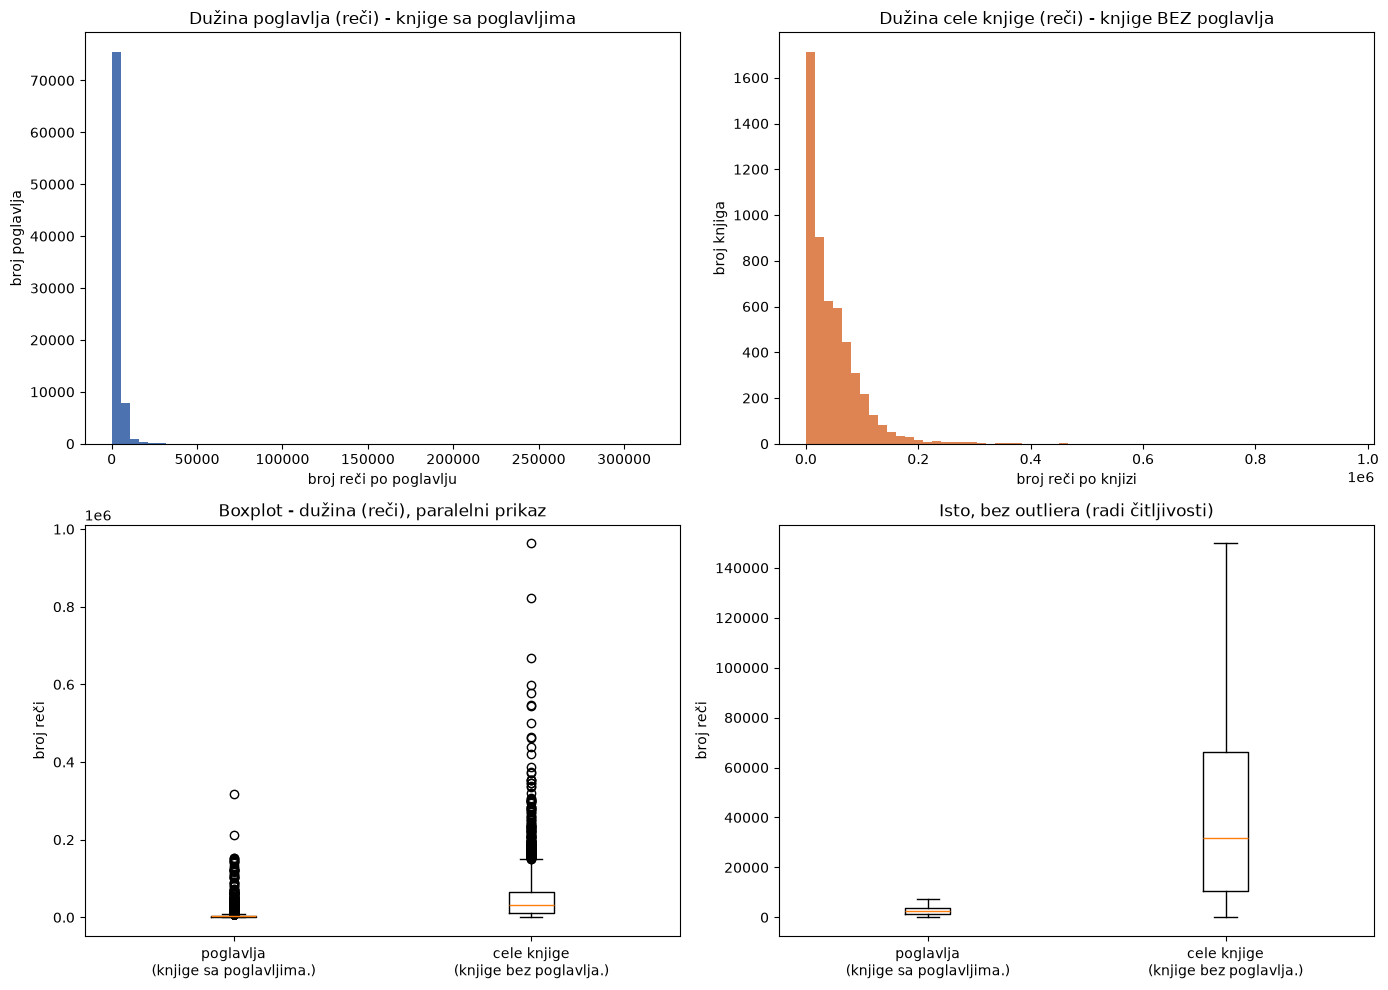

Histogram/boxplot sačuvan na putanji: ..\data\stats\probe_length_distributions.png


In [139]:
plot_length_distributions(df, output_dir)